# Autoencoder CASIA v2.0 — Complete Faculty Demo

Run this notebook directly in VS Code using the project's `.venv` Python kernel. It loads the local dataset, epoch-20 checkpoint, complete training history, plots, and final test results without retraining.

In [37]:
# Faculty demo mode loads saved results without retraining.
TRAIN_STANDARD_AE = False
TRAIN_DENOISING_AE = True
REPO_URL = "https://github.com/chetanraje27/Digital-Evidence-GenAI.git"
DATASET_HANDLE = "divg07/casia-20-image-tampering-detection-dataset"
print("TRAIN_STANDARD_AE =", TRAIN_STANDARD_AE)
print("TRAIN_DENOISING_AE =", TRAIN_DENOISING_AE)

TRAIN_STANDARD_AE = False
TRAIN_DENOISING_AE = True


## 1 — Project Introduction

**Project:** Multi-Model Generative AI Framework for Digital Evidence Analysis and Intelligence Generation  
**Component demonstrated here:** Convolutional Autoencoder  
**Dataset:** CASIA v2.0 Image Tampering Detection Dataset

The Autoencoder objectives are image reconstruction, meaningful dimensionality reduction, a later denoising experiment, and exploratory comparison of reconstruction behavior for authentic and tampered images. Authentic/tampered labels are retained only for analysis. This model is **not** claimed to be an automatic forgery detector.

## 2 — Environment and GPU

In [38]:
import os, sys, platform, subprocess
from pathlib import Path
import torch

IS_COLAB = Path("/content").exists()
if IS_COLAB:
    PROJECT_ROOT = Path("/content/Digital-Evidence-GenAI")
    if not PROJECT_ROOT.exists():
        subprocess.run(["git", "clone", REPO_URL, str(PROJECT_ROOT)], check=True)
    else:
        subprocess.run(["git", "-C", str(PROJECT_ROOT), "pull", "--ff-only"], check=True)
else:
    root_candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent]
    PROJECT_ROOT = next(
        (root for root in root_candidates if (root / "src/autoencoder.py").is_file()), None
    )
    assert PROJECT_ROOT is not None, "Open this notebook from the project repository in VS Code."

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GPU_NAME = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Not available (saved GPU results are loaded)"
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", GPU_NAME)
print("Selected device:", DEVICE)
print("Project root:", PROJECT_ROOT)

Python: 3.12.10
PyTorch: 2.13.0+cpu
CUDA available: False
GPU: Not available (saved GPU results are loaded)
Selected device: cpu
Project root: C:\Users\Chetanraje\Desktop\GAA\Digital_Evidence


## 3 — Dataset Overview

The main AE dataset contains **12,614 RGB images**: 7,491 authentic and 5,123 tampered. The separate 5,123 ground-truth PNG masks are excluded from normal Autoencoder inputs.

,Class,Images
0,Authentic,7491
1,Tampered,5123
2,Ground-truth masks (excluded),5123


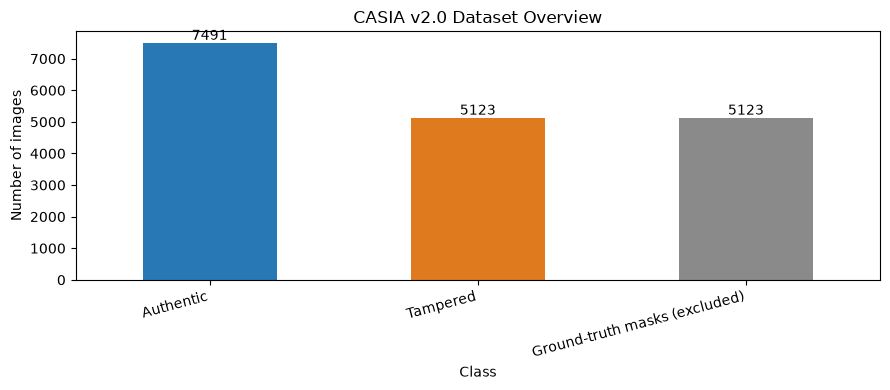

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

RAW_DATA_DIR = PROJECT_ROOT / "data/raw"
EXPECTED_CASIA_DIR = RAW_DATA_DIR / "CASIA2"
if not (EXPECTED_CASIA_DIR / "Au").is_dir():
    assert IS_COLAB, "Local CASIA dataset is missing from data/raw/CASIA2."
    import kagglehub
    downloaded_root = Path(kagglehub.dataset_download(DATASET_HANDLE)).resolve()
    candidates = [downloaded_root] + list(downloaded_root.rglob("CASIA2"))
    actual = next(
        (item for item in candidates if (item / "Au").is_dir() and (item / "Tp").is_dir()), None
    )
    assert actual is not None, f"CASIA2 folders not found under {downloaded_root}"
    RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
    if EXPECTED_CASIA_DIR.is_symlink():
        EXPECTED_CASIA_DIR.unlink()
    EXPECTED_CASIA_DIR.symlink_to(actual, target_is_directory=True)

dataset_counts = pd.DataFrame({
    "Class": ["Authentic", "Tampered", "Ground-truth masks (excluded)"],
    "Images": [7491, 5123, 5123],
})
display(dataset_counts)
ax = dataset_counts.plot.bar(
    x="Class", y="Images", legend=False,
    color=["#2878B5", "#E07A1F", "#8A8A8A"], figsize=(9, 4),
)
ax.set_title("CASIA v2.0 Dataset Overview")
ax.set_ylabel("Number of images")
ax.bar_label(ax.containers[0])
plt.xticks(rotation=15, ha="right")
plt.tight_layout(); plt.show()

In [40]:
assert (EXPECTED_CASIA_DIR / "Au/Au_ani_00001.jpg").is_file()
assert (EXPECTED_CASIA_DIR / "Tp").is_dir()
assert (PROJECT_ROOT / "checkpoints/best_autoencoder.pth").is_file()
assert (PROJECT_ROOT / "results/ae_training_history.csv").is_file()
assert (PROJECT_ROOT / "results/ae_test_metrics.json").is_file()
print("CASIA dataset, standard checkpoint, history, and test metrics: READY")

CASIA dataset, standard checkpoint, history, and test metrics: READY


## 4 — Sample Digital Evidence

Authentic and tampered examples are displayed with their preserved metadata labels.

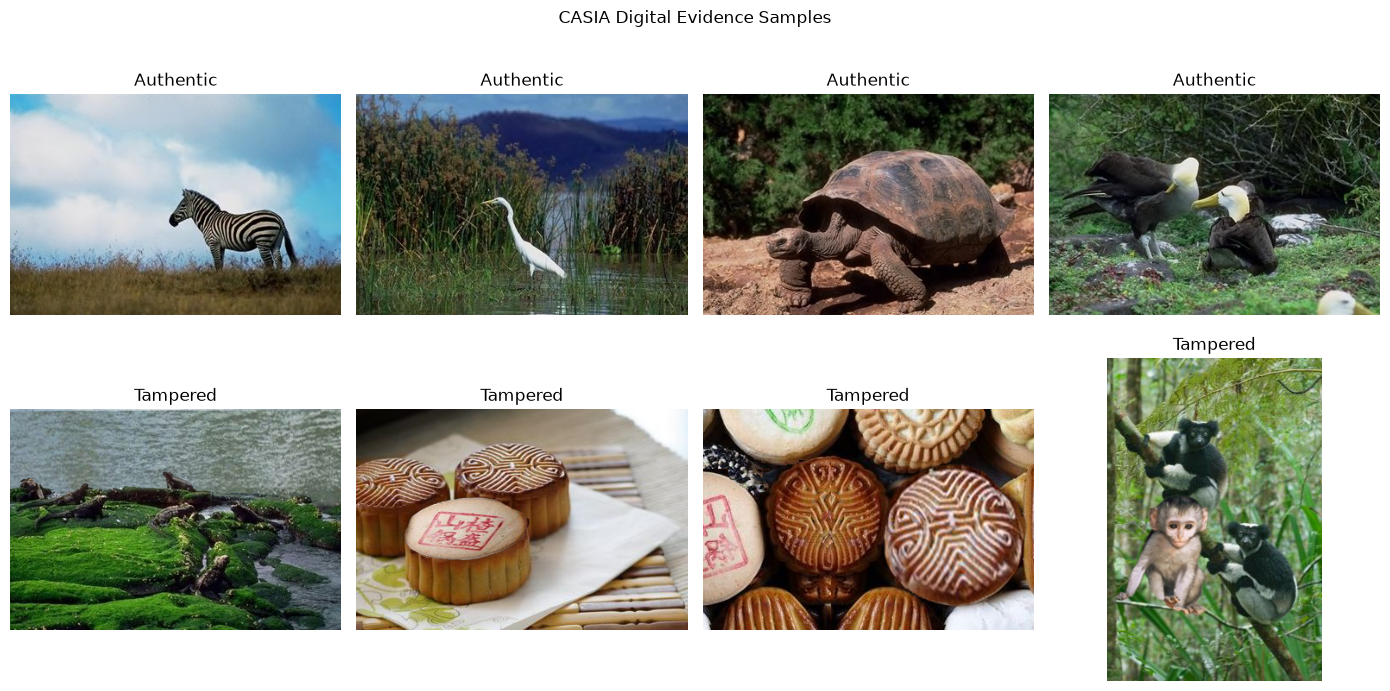

In [41]:
from PIL import Image
import csv

with (PROJECT_ROOT / "data/splits/train.csv").open(newline="", encoding="utf-8") as file:
    training_rows = list(csv.DictReader(file))
sample_rows = [r for r in training_rows if r["class_name"] == "authentic"][:4] + [r for r in training_rows if r["class_name"] == "tampered"][:4]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, row in zip(axes.flat, sample_rows):
    with Image.open(PROJECT_ROOT / row["image_path"]) as image:
        ax.imshow(image.convert("RGB"))
    ax.set_title(row["class_name"].title())
    ax.axis("off")
fig.suptitle("CASIA Digital Evidence Samples"); plt.tight_layout(); plt.show()

## 5 — Data Preprocessing

Each image is safely opened with PIL, converted to RGB, resized to 128×128, converted to a channel-first PyTorch tensor, and scaled to [0,1]. ImageNet normalization is not used.

In [42]:
from ae_dataset import create_ae_dataloaders

loaders = create_ae_dataloaders(PROJECT_ROOT / "data/splits", image_size=128, batch_size=32, num_workers=0, seed=42)
example_batch = next(iter(loaders["train"]))
print("Input tensor shape:", list(example_batch["image"].shape))
print("Pixel minimum:", float(example_batch["image"].min()))
print("Pixel maximum:", float(example_batch["image"].max()))

Input tensor shape: [32, 3, 128, 128]
Pixel minimum: 0.0
Pixel maximum: 1.0


## 6 — Data Splitting

The fixed seed is 42. Splits are reproducible and stratified, with zero duplicate leakage and zero ground-truth mask leakage.

In [43]:
import json
pipeline_summary = json.loads((PROJECT_ROOT / "results/ae_data_pipeline_summary.json").read_text())
split_table = pd.DataFrame([
    {"Split": name.title(), "Total": pipeline_summary["split_counts"][name], **pipeline_summary["class_counts"][name]}
    for name in ("train", "validation", "test")
]).rename(columns={"authentic": "Authentic", "tampered": "Tampered"})
display(split_table)
print("Duplicate leakage:", pipeline_summary["duplicate_count_across_splits"])
print("Ground-truth mask leakage:", pipeline_summary["ground_truth_mask_count_accidentally_included"])

,Split,Total,Authentic,Tampered
0,Train,8830,5244,3586
1,Validation,1892,1124,768
2,Test,1892,1123,769


Duplicate leakage: 0
Ground-truth mask leakage: 0


## 7 — Autoencoder Architecture

The encoder progressively reduces spatial dimensions to a compact latent representation. The decoder mirrors that process to reconstruct the original RGB image.

In [44]:
from autoencoder import ConvolutionalAutoencoder
model = ConvolutionalAutoencoder().to(DEVICE)
architecture_table = pd.DataFrame([
    ["Input", "3 × 128 × 128", "49,152"],
    ["Encoder 1", "32 × 64 × 64", "—"],
    ["Encoder 2", "64 × 32 × 32", "—"],
    ["Encoder 3", "64 × 16 × 16", "—"],
    ["Latent", "32 × 8 × 8", "2,048"],
    ["Output", "3 × 128 × 128", "49,152"],
], columns=["Stage", "Shape", "Values per image"])
display(architecture_table)
print("Compression ratio: 24×")
print("Parameters:", sum(p.numel() for p in model.parameters()))

,Stage,Shape,Values per image
0,Input,3 × 128 × 128,"49,152"
1,Encoder 1,32 × 64 × 64,—
2,Encoder 2,64 × 32 × 32,—
3,Encoder 3,64 × 16 × 16,—
4,Latent,32 × 8 × 8,"2,048"
5,Output,3 × 128 × 128,"49,152"


Compression ratio: 24×
Parameters: 265571


## 8 — Training Configuration

In [45]:
display(pd.DataFrame({"Setting": ["Loss", "Optimizer", "Learning rate", "Batch size", "Maximum epochs", "Early-stopping patience"], "Value": ["MSELoss", "Adam", 0.001, 32, 20, 4]}))

,Setting,Value
0,Loss,MSELoss
1,Optimizer,Adam
2,Learning rate,0.001
3,Batch size,32
4,Maximum epochs,20
5,Early-stopping patience,4


## 9 — Training Control

`TRAIN_MODEL=False` loads the existing epoch-20 checkpoint for a quick faculty demonstration. Set it to `True` only when a GPU retraining run is intended.

In [46]:
from argparse import Namespace

checkpoint_path = PROJECT_ROOT / "checkpoints/best_autoencoder.pth"
history_path = PROJECT_ROOT / "results/ae_training_history.csv"

if TRAIN_STANDARD_AE:
    # Imported only for a deliberate GPU retraining run. Demo mode keeps the
    # notebook's inline plotting backend active.
    import importlib
    import train_autoencoder
    importlib.reload(train_autoencoder)
    assert DEVICE.type == "cuda", "Enable a CUDA GPU before full training."
    training_summary = train_autoencoder.train(Namespace(
        splits_dir=PROJECT_ROOT / "data/splits",
        checkpoint_path=checkpoint_path,
        history_path=history_path,
        curve_path=PROJECT_ROOT / "outputs/ae/ae_training_curve.png",
        grid_path=PROJECT_ROOT / "outputs/ae/trained_reconstruction_grid.png",
        image_size=128, batch_size=32, num_workers=0,
        learning_rate=0.001, max_epochs=20, patience=4,
        seed=42, smoke_test=False,
    ))
else:
    assert checkpoint_path.is_file(), f"Missing trained checkpoint: {checkpoint_path}"
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
    assert checkpoint["epoch"] == 20, f"Expected epoch-20 checkpoint, found epoch {checkpoint['epoch']}"
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    print("Loaded best checkpoint from epoch", checkpoint["epoch"])
    print("Training skipped: using saved epoch-20 results.")

Loaded best checkpoint from epoch 20
Training skipped: using saved epoch-20 results.


## 10 — Training Results

,Result,Value
0,Epochs completed,20
1,First training loss,0.027932
2,Final training loss,0.004299
3,Best validation loss,0.004161
4,Best epoch,20
5,Training GPU,Tesla T4
6,Training time,733.16 seconds


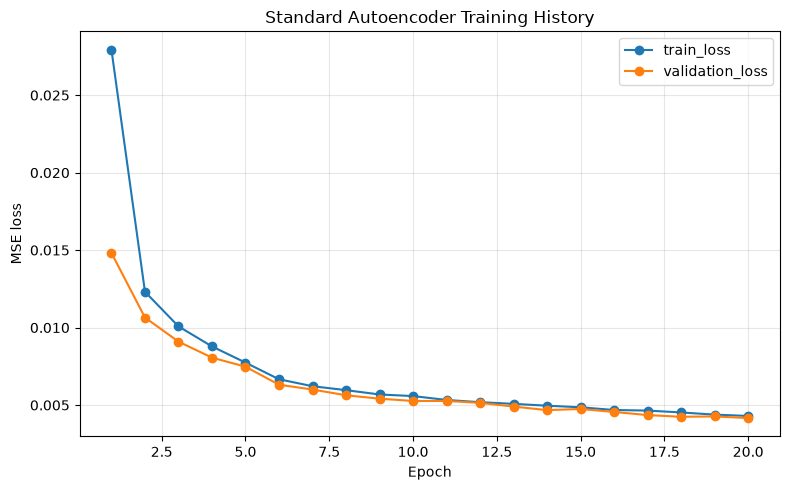

In [47]:
training_results = pd.DataFrame({
    "Result": [
        "Epochs completed", "First training loss", "Final training loss",
        "Best validation loss", "Best epoch", "Training GPU", "Training time",
    ],
    "Value": [20, 0.0279316258, 0.0042993340, 0.0041614504, 20, "Tesla T4", "733.16 seconds"],
})
display(training_results)

history = pd.read_csv(history_path)
assert len(history) == 20, f"Expected 20 training-history rows, found {len(history)}"
ax = history.plot(
    x="epoch", y=["train_loss", "validation_loss"], marker="o",
    figsize=(8, 5), title="Standard Autoencoder Training History",
)
ax.set_ylabel("MSE loss")
ax.set_xlabel("Epoch")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11 — Reconstruction Results

Examples below come only from the held-out test split.

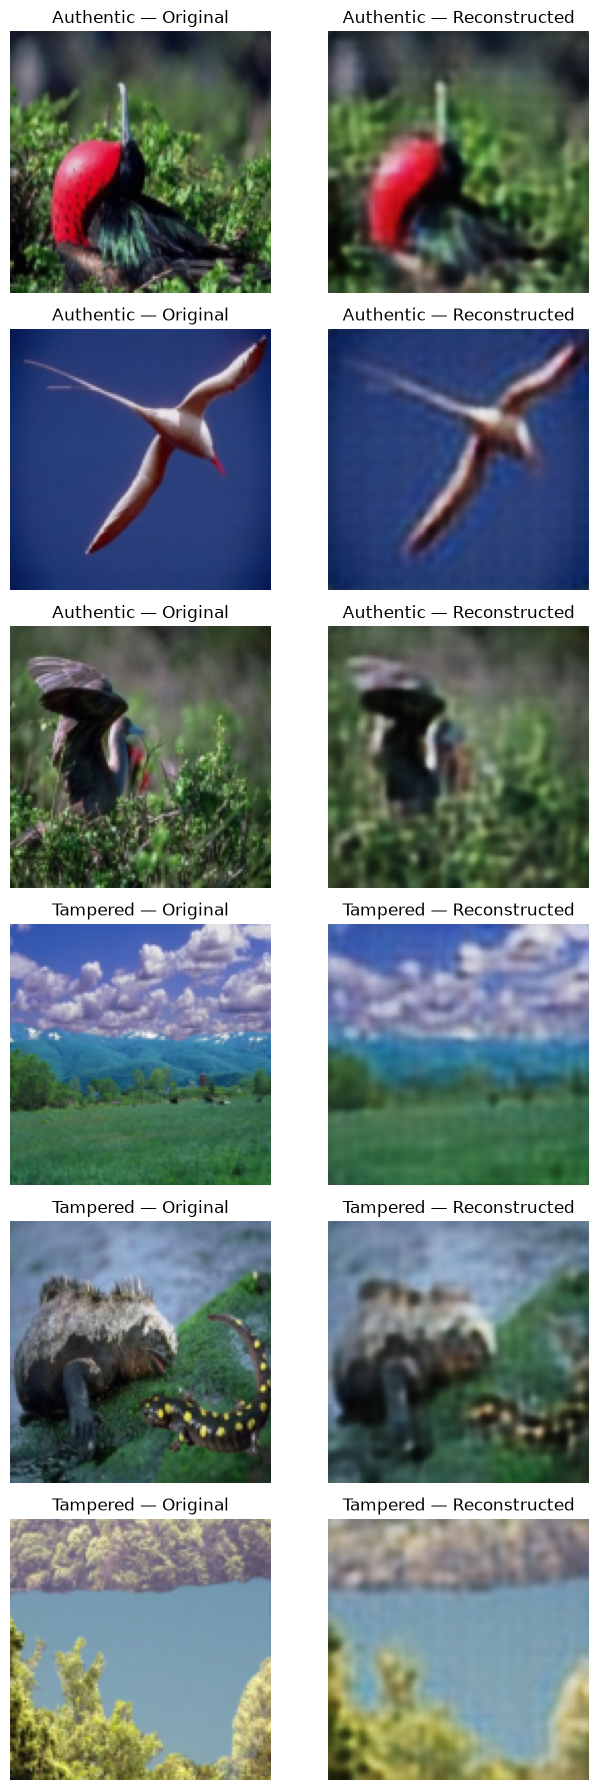

In [48]:
selected_images, selected_names = [], []
class_counts = {"authentic": 0, "tampered": 0}
for batch in loaders["test"]:
    for image, name in zip(batch["image"], batch["class_name"]):
        if class_counts[name] < 3:
            selected_images.append(image); selected_names.append(name); class_counts[name] += 1
    if all(count == 3 for count in class_counts.values()): break
test_inputs = torch.stack(selected_images).to(DEVICE)
with torch.no_grad(): test_outputs = model(test_inputs).cpu()
fig, axes = plt.subplots(len(selected_images), 2, figsize=(7, 3*len(selected_images)))
for row, (original, class_name) in enumerate(zip(selected_images, selected_names)):
    name = class_name.title()
    axes[row,0].imshow(original.permute(1,2,0)); axes[row,0].set_title(f"{name} — Original")
    axes[row,1].imshow(test_outputs[row].permute(1,2,0)); axes[row,1].set_title(f"{name} — Reconstructed")
    axes[row,0].axis("off"); axes[row,1].axis("off")
plt.tight_layout(); plt.show()

## 12 — Test Metrics

MSE is better when lower, PSNR is better when higher, and SSIM is better when closer to 1.

In [49]:
test_metrics = json.loads((PROJECT_ROOT / "results/ae_test_metrics.json").read_text())
overall = test_metrics["overall"]
display(pd.DataFrame({"Metric": ["MSE", "PSNR (dB)", "SSIM"], "Test mean": [overall["mse_mean"], overall["psnr_mean"], overall["ssim_mean"]]}))

,Metric,Test mean
0,MSE,0.004134
1,PSNR (dB),24.560326
2,SSIM,0.725357


## 13 — Authentic vs Tampered Analysis

The Autoencoder showed slightly higher reconstruction error and lower structural similarity for tampered images. This is an exploratory observation only; the model was not trained or validated as a forgery classifier.

,Class,MSE,PSNR (dB),SSIM
0,Authentic,0.004004,24.691980,0.730084
1,Tampered,0.004324,24.368066,0.718454


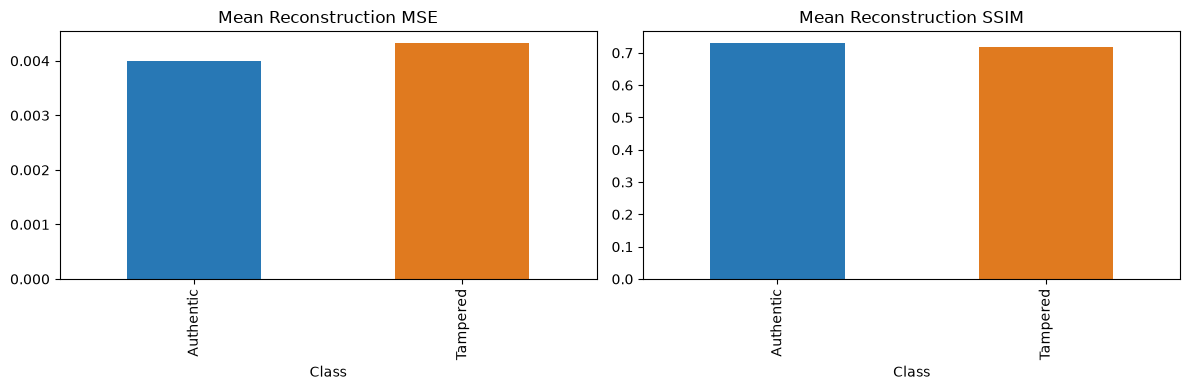

In [50]:
comparison = pd.DataFrame([
    {"Class": name.title(), "MSE": test_metrics[name]["mse_mean"], "PSNR (dB)": test_metrics[name]["psnr_mean"], "SSIM": test_metrics[name]["ssim_mean"]}
    for name in ("authentic", "tampered")])
display(comparison)
fig, axes = plt.subplots(1, 2, figsize=(12,4))
comparison.plot.bar(x="Class", y="MSE", ax=axes[0], legend=False, color=["#2878B5", "#E07A1F"], title="Mean Reconstruction MSE")
comparison.plot.bar(x="Class", y="SSIM", ax=axes[1], legend=False, color=["#2878B5", "#E07A1F"], title="Mean Reconstruction SSIM")
plt.tight_layout(); plt.show()

## 14 — Denoising Autoencoder

The same 24× convolutional Autoencoder is fine-tuned to recover a clean image from a noisy input. For clean image $x$, Gaussian noise is added as

$$x_{noisy} = \operatorname{clamp}(x + \epsilon, 0, 1), \qquad \epsilon \sim \mathcal{N}(0, 0.10^2).$$

The noisy image is the input and the original clean image is the target. Fine-tuning starts from the standard AE checkpoint; it does not train from scratch.

| Setting | Value |
|---|---:|
| Noise standard deviation | 0.10 |
| Optimizer | Adam |
| Learning rate | 0.0005 |
| Loss | MSELoss |
| Maximum epochs | 8 |
| Early-stopping patience | 3 |

In [51]:
import json
from argparse import Namespace
from IPython.display import Image as NotebookImage

NOISE_STD = 0.10
dae_checkpoint = PROJECT_ROOT / "checkpoints/best_denoising_autoencoder.pth"
dae_history_path = PROJECT_ROOT / "results/dae_training_history.csv"
dae_summary_path = PROJECT_ROOT / "results/dae_training_summary.json"
dae_metrics_path = PROJECT_ROOT / "results/dae_test_metrics.json"

if TRAIN_DENOISING_AE:
    assert DEVICE.type == "cuda", "Use a Google Colab GPU for full denoising fine-tuning."
    import train_denoising_autoencoder
    import evaluate_denoising_autoencoder
    dae_train_args = Namespace(
        splits_dir=PROJECT_ROOT/"data/splits",
        standard_checkpoint=PROJECT_ROOT/"checkpoints/best_autoencoder.pth",
        checkpoint_path=dae_checkpoint,
        history_path=dae_history_path,
        curve_path=PROJECT_ROOT/"outputs/ae/dae_training_curve.png",
        summary_path=dae_summary_path,
        image_size=128, batch_size=32, num_workers=0, noise_std=NOISE_STD,
        learning_rate=0.0005, max_epochs=8, patience=3, seed=42,
    )
    dae_training_summary = train_denoising_autoencoder.train(dae_train_args)
    dae_eval_args = Namespace(
        splits_dir=PROJECT_ROOT/"data/splits", checkpoint_path=dae_checkpoint,
        metrics_json=dae_metrics_path,
        per_image_csv=PROJECT_ROOT/"results/dae_test_per_image_metrics.csv",
        comparison_csv=PROJECT_ROOT/"results/ae_final_comparison.csv",
        standard_metrics=PROJECT_ROOT/"results/ae_test_metrics.json",
        grid_path=PROJECT_ROOT/"outputs/ae/denoising_comparison_grid.png",
        image_size=128, batch_size=32, num_workers=0, noise_std=NOISE_STD,
        samples_per_class=3, seed=42,
    )
    dae_metrics = evaluate_denoising_autoencoder.evaluate(dae_eval_args)

DAE_RESULTS_READY = all(path.is_file() for path in (
    dae_checkpoint, dae_history_path, dae_summary_path, dae_metrics_path,
    PROJECT_ROOT/"results/ae_final_comparison.csv",
    PROJECT_ROOT/"outputs/ae/denoising_comparison_grid.png",
))
if DAE_RESULTS_READY:
    dae_training_summary = json.loads(dae_summary_path.read_text())
    dae_metrics = json.loads(dae_metrics_path.read_text())
    print("Loaded saved Denoising Autoencoder checkpoint and results.")
else:
    print("Denoising GPU results are pending. Set TRAIN_DENOISING_AE=True in Colab once.")

AssertionError: Use a Google Colab GPU for full denoising fine-tuning.

In [ ]:
if DAE_RESULTS_READY:
    dae_history = pd.read_csv(dae_history_path)
    display(pd.DataFrame({
        "Result": ["Epochs completed", "Best epoch", "Best validation loss", "Training GPU", "Training time (s)"],
        "Value": [
            dae_training_summary["epochs_completed"], dae_training_summary["best_epoch"],
            dae_training_summary["best_validation_loss"], dae_training_summary["gpu"],
            dae_training_summary["training_time_seconds"],
        ],
    }))
    display(NotebookImage(filename=str(PROJECT_ROOT/"outputs/ae/dae_training_curve.png")))
    display(NotebookImage(filename=str(PROJECT_ROOT/"outputs/ae/denoising_comparison_grid.png")))
    display(pd.DataFrame([
        {"Input": "Noisy input", **dae_metrics["noisy_input"]},
        {"Input": "Denoised output", **dae_metrics["denoised_output"]},
    ]))
    display(pd.DataFrame([dae_metrics["improvement"]]))
else:
    display(pd.DataFrame({"Denoising result": ["Pending one Colab T4 run"]}))

,Denoising result
0,Pending one Colab T4 run


## 15 — Final Standard AE vs Denoising AE Comparison

In [ ]:
if DAE_RESULTS_READY:
    final_comparison = pd.read_csv(PROJECT_ROOT / "results/ae_final_comparison.csv")
else:
    standard = test_metrics["overall"]
    final_comparison = pd.DataFrame([
        ["Standard Autoencoder", standard["mse_mean"], standard["psnr_mean"], standard["ssim_mean"], 24, 265571],
        ["Noisy Input", "Pending GPU run", "Pending GPU run", "Pending GPU run", "N/A", "N/A"],
        ["Denoised Output", "Pending GPU run", "Pending GPU run", "Pending GPU run", 24, 265571],
    ], columns=["experiment", "mse", "psnr", "ssim", "compression_ratio", "parameter_count"])
display(final_comparison)

,experiment,mse,psnr,ssim,compression_ratio,parameter_count
0,Standard Autoencoder,0.004134,24.560326,0.725357,24,265571
1,Noisy Input,Pending GPU run,Pending GPU run,Pending GPU run,N/A,N/A
2,Denoised Output,Pending GPU run,Pending GPU run,Pending GPU run,24,265571


## 16 — Conclusion

- CASIA images were reconstructed with a genuine **24× latent compression**.
- Standard AE quality was measured on all 1,892 held-out images using MSE, PSNR, and SSIM.
- Authentic/tampered reconstruction differences remain exploratory and are not proof of forgery.
- The Denoising AE uses the same architecture and learns noisy-to-clean reconstruction.
- Denoising is evaluated against the clean target and compared with the noisy input.
- Neither experiment is claimed to be a standalone forgery detector.

In [ ]:
if DAE_RESULTS_READY:
    print("GPU:", dae_training_summary["gpu"])
    print("Noise std:", dae_metrics["noise_std"])
    print("Epochs completed:", dae_training_summary["epochs_completed"])
    print("Best epoch:", dae_training_summary["best_epoch"])
    print("Best validation loss:", dae_training_summary["best_validation_loss"])
    print("Training time:", dae_training_summary["training_time_seconds"])
    print("NOISY INPUT:", dae_metrics["noisy_input"])
    print("DENOISED OUTPUT:", dae_metrics["denoised_output"])
    print("IMPROVEMENT:", dae_metrics["improvement"])
    print("Checkpoint path:", dae_training_summary["checkpoint_path"])
    print("Errors/warnings: None")
else:
    print("Denoising results pending: run once on Colab T4 with TRAIN_DENOISING_AE=True.")

Denoising results pending: run once on Colab T4 with TRAIN_DENOISING_AE=True.
